# STA365 Homework 7

### Question 1

### Question 2

For this question, I will be using the Salary_dataset from: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression/data.

In [1]:
import pandas
salary_data = pandas.read_csv('Salary_dataset.csv')
salary_data

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


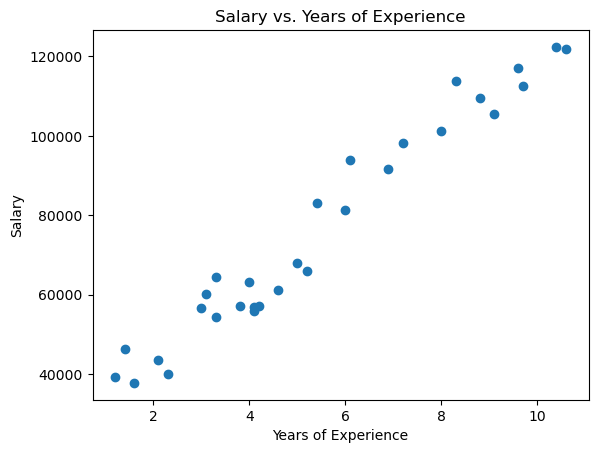

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(salary_data["YearsExperience"], salary_data["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs. Years of Experience")
plt.show()

In [7]:
mean_salary = salary_data["Salary"].mean()
sd_salary = salary_data["Salary"].std()

print("Mean Salary:", mean_salary)
print("Salary Standard Deviation:", sd_salary)

Mean Salary: 76004.0
Salary Standard Deviation: 27414.4297845823


In [8]:
import numpy as np
import pymc as pm
import arviz as az

X = np.column_stack((np.ones(len(salary_data)), salary_data["YearsExperience"].values))
y = salary_data["Salary"].values
np.random.seed(36)

with pm.Model() as model:
    # priors for intercept and slope using pm.Normal, larger values of mu and sigma reflect the Salary_data better
    betas = pm.Normal("betas", mu=25000, sigma=10000, shape=X.shape[1])
    # HalfNormal prior for sigma
    sigma = pm.HalfNormal("sigma", sigma=10000)
    
    # likelihood using pm.Normal
    y_obs = pm.Normal("y", mu=X@betas, sigma=sigma, observed=y)
    
    # sample
    trace = pm.sample(draws=3000, tune=1000, chains=4, random_seed=36)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, sigma]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 14 seconds.


In [9]:
az.summary(trace, var_names=["betas", "sigma"], round_to=5)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],24723.31009,2356.27267,20228.23189,29075.84334,34.43101,24.42262,4702.84980,5456.43449,1.00034
betas[1],9474.54292,390.68241,8732.88356,10181.24963,5.67487,4.01824,4760.86209,5382.58841,1.00019
sigma,6018.74806,834.27901,4519.35163,7557.52946,10.65253,7.59972,6184.52778,6295.65233,1.00106


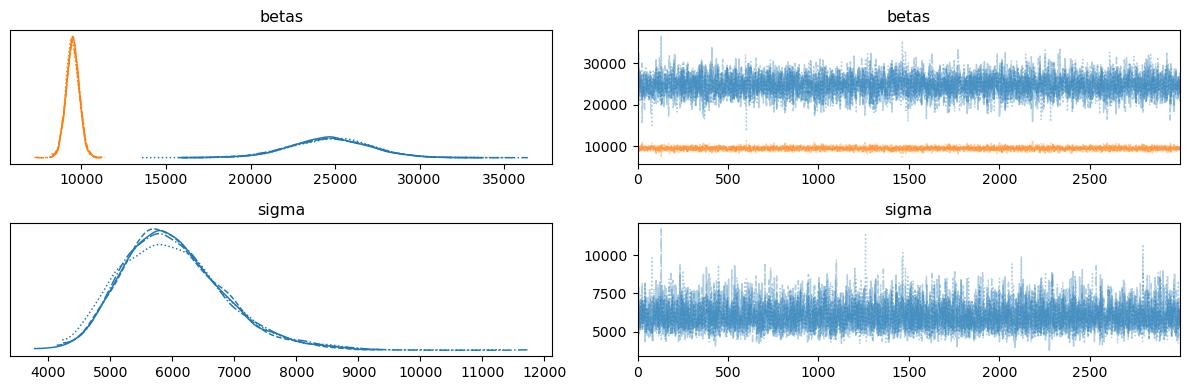

In [10]:
import matplotlib.pyplot as plt

az.plot_trace(trace, var_names=["betas", "sigma"])
plt.tight_layout()
plt.show()

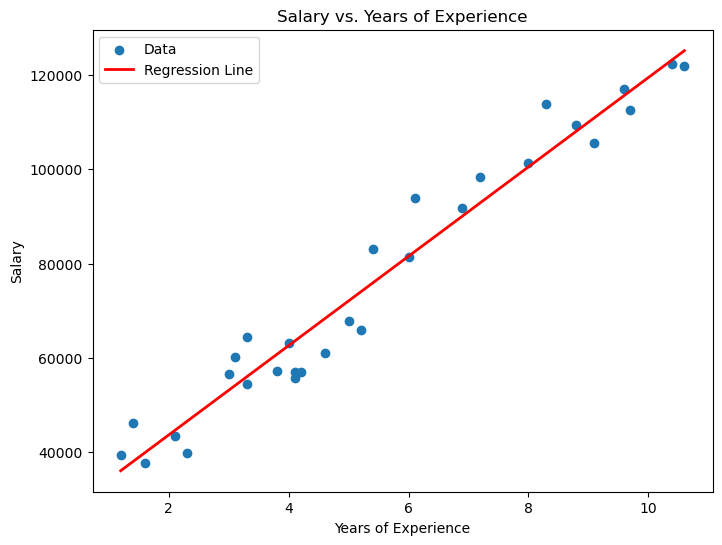

In [15]:
beta0 = 24723.31009  # copied from summary
beta1 = 9474.54292   # copied from summary

x_line = np.linspace(salary_data["YearsExperience"].min(), salary_data["YearsExperience"].max(), 100)
y_line = beta0 + beta1 * x_line

plt.figure(figsize=(8, 6))
plt.scatter(salary_data["YearsExperience"], salary_data["Salary"], label="Data")
plt.plot(x_line, y_line, color='red', linewidth=2, label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs. Years of Experience")
plt.legend()
plt.show()

#### Inference with Bayesian posterior analysis and MCMC diagnostics

* The r_hat statistic for beta0, beta1, and sigma are all very close to 1, indicating the chains are mixing well and converging on the same result.
* From the scatterplot above, it seems that our algorithm did a good job estimating beta0 and beta1, as the resulting regression line fits the data well. The mean estimate of sigma as given in the summary is 6018.74806, which looks reasonable, as this value represents the Salary deviation from the regression line after Years of Experience is accounted for. Having a low sigma relative to the scale of the data implies that the regression line fits the data well, as can be seen in the scatterplot diagram.
* From the trace plots above, we see that the chains are in agreement and have converged closely for each parameter.
* The 94% HDIs for all three parameters are relatively narrow given the large scale of the data, indicating the model is confident about these estimates.
* In this example, we took a total of 12,000 draws. ess_bulk is approximately 4703 for beta0, 4761 for beta1, and 6185 for sigma. This means we took the rough equivalent of this many independent samples for each respective parameter. Having the rough equivalent of this many samples for each parameter seems sufficient, as our other diagnostics explained in the previous points suggest the chains have converged and have mixed well.

Overall, our analysis shows that this algorithm provided a reliable estimate of the relationship between Years of Experience and Salary using Bayesian linear regression.

### Question 3

For this question, I modified the Salary_dataset to have 3 outliers out of the 30 data points. I modified the 5th, 23rd, and 28th data points.

In [3]:
import pandas
salary_data_outliers = pandas.read_csv('Salary_dataset_with outliers.csv')

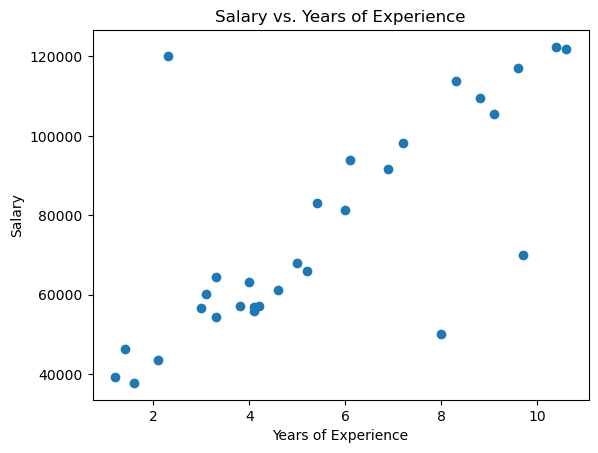

In [4]:
plt.figure()
plt.scatter(salary_data_outliers["YearsExperience"], salary_data_outliers["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs. Years of Experience")
plt.show()

In [11]:
X = np.column_stack((np.ones(len(salary_data_outliers)), salary_data_outliers["YearsExperience"].values))
y = salary_data_outliers["Salary"].values
n = len(y)
np.random.seed(36)


with pm.Model() as robust_model:
    betas = pm.Normal("betas", mu=25000, sigma=10000, shape=X.shape[1])
    sigma = pm.HalfNormal("sigma", sigma=10000)
    alpha = pm.Exponential("alpha", 0.1)   # shape parameter
    beta_rate = pm.Exponential("beta", 0.1)  # rate parameter
    
    # precision for each data point
    tau = pm.Gamma("tau", alpha=alpha, beta=beta_rate, shape=n)
    
    mu = pm.math.dot(X, betas)
    
    # likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma / pm.math.sqrt(tau), observed=y)
    
    trace_robust = pm.sample(
        draws=3000, 
        tune=1000, 
        chains=4, 
        target_accept=0.95, 
        random_seed=36
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, sigma, alpha, beta, tau]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 50 seconds.


In [12]:
az.summary(trace_robust, var_names=["betas", "sigma", "alpha", "beta"], round_to=5)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],25400.91899,2859.67196,20165.53564,31005.87087,43.22786,30.84785,4397.61334,5570.79684,1.00068
betas[1],9314.60608,456.08677,8433.80792,10146.68540,6.82845,4.82876,4520.25940,5244.96107,1.00104
sigma,4269.18785,3408.14485,497.05988,10461.84960,139.50242,98.69135,531.47633,1252.12992,1.00458
alpha,0.94954,0.37513,0.38198,1.62015,0.00822,0.00591,2258.69139,3123.96944,1.00138
beta,6.17909,7.59526,0.02828,19.71742,0.24937,0.17639,636.80368,1379.90281,1.00383


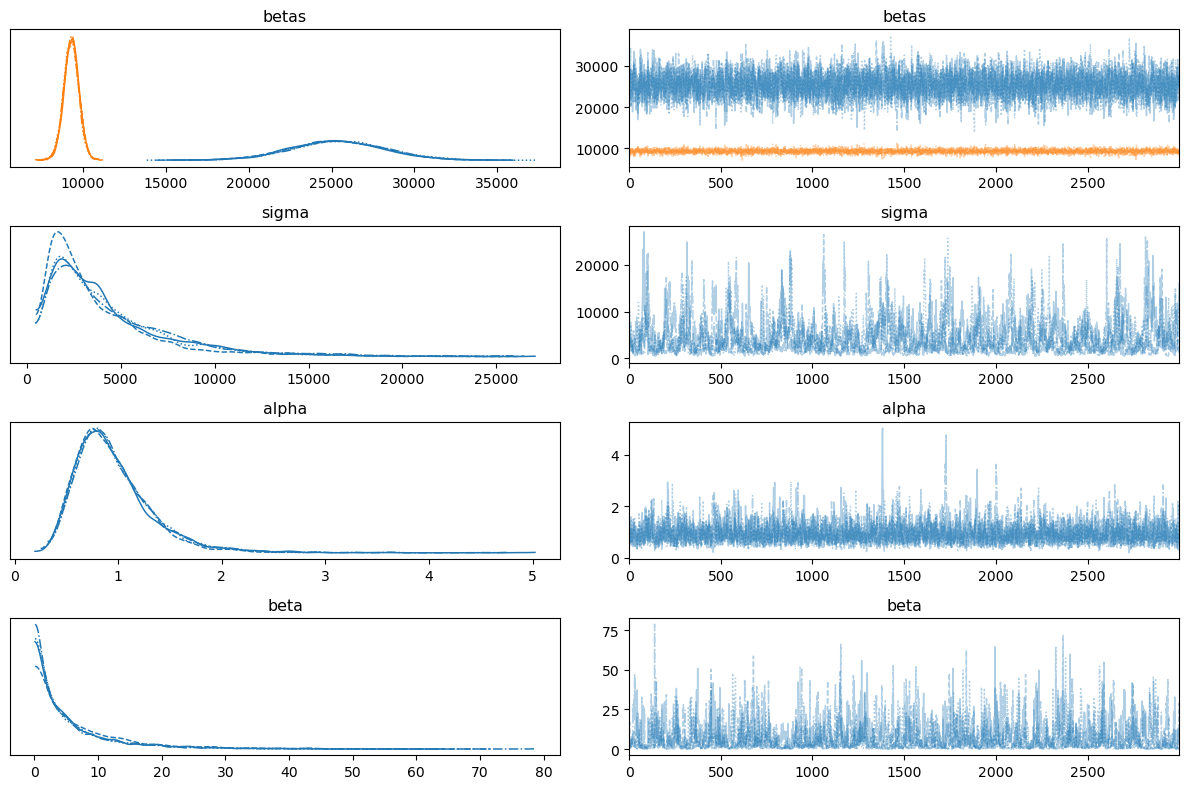

In [13]:
az.plot_trace(trace_robust, var_names=["betas", "sigma", "alpha", "beta"])
plt.tight_layout()
plt.show()

In [17]:
# posterior samples for tau
tau_samples = trace_robust.posterior["tau"]

# tau median across chains and draws
tau_median = tau_samples.median(dim=("chain","draw")).values

# sort data points to identify outliers
sorted_indices = np.argsort(tau_median)
for i in sorted_indices[:5]:
    print(f"Potential outlier index: {i+1}, tau ~ {tau_median[i]:.2f}, Salary = {y[i]}")

Potential outlier index: 5, tau ~ 0.00, Salary = 120000.0
Potential outlier index: 23, tau ~ 0.01, Salary = 50000.0
Potential outlier index: 28, tau ~ 0.01, Salary = 70000.0
Potential outlier index: 20, tau ~ 0.10, Salary = 93941.0
Potential outlier index: 24, tau ~ 0.11, Salary = 113813.0


Here, we see the algorithm identifies the above five data points as potential outliers. The 5th, 23rd, and 28th data points (the three I have modified) are identified to have very small precision values (0.00, 0.01, and 0.01 respectively), showing the model has a high level of belief that these points are outliers. The model also suspects that the 20th and 24th data point could be outliers, but with less certainty compared to the first three (the model gives these points higher precision values of 0.10 and 0.11).

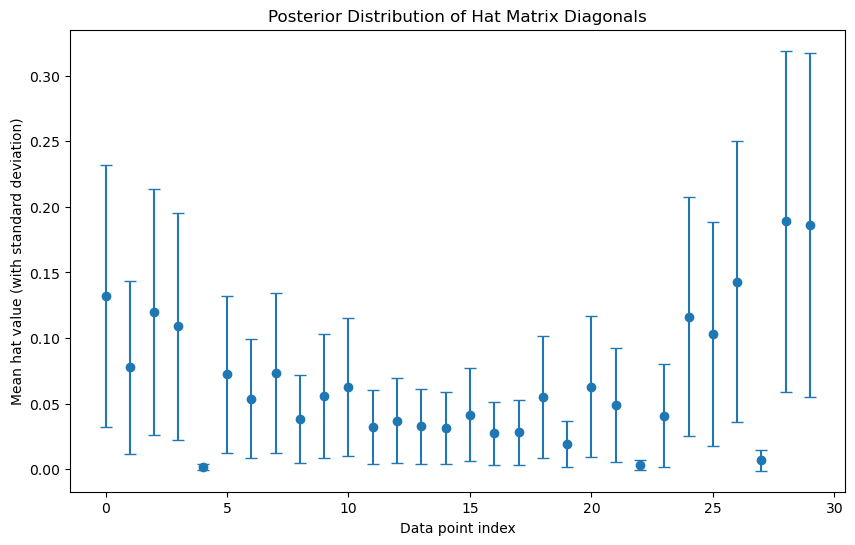

In [15]:
tau_samples = trace_robust.posterior["tau"].values
n_chains, n_draws, n_points = tau_samples.shape

tau_flat = tau_samples.reshape(-1, n_points)

# compute hat matrix diagonal for each posterior sample
h_diagonals = []
for i in range(tau_flat.shape[0]):
    tau_i = tau_flat[i]
    W = np.diag(tau_i)
    XTWX = X.T @ W @ X
    XTWX_inv = np.linalg.inv(XTWX)
    # compute the hat matrix
    H = X @ XTWX_inv @ X.T @ W
    h_diag = np.diag(H)
    h_diagonals.append(h_diag)

h_diagonals = np.array(h_diagonals)

# mean and standard deviation of h_ii across posterior samples for each data point
h_mean = h_diagonals.mean(axis=0)
h_std = h_diagonals.std(axis=0)

# posterior mean hat values with std dev for each observation
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(n_points), h_mean, yerr=h_std, fmt="o", capsize=4)
plt.xlabel("Data point index")
plt.ylabel("Mean hat value (with standard deviation)")
plt.title("Posterior Distribution of Hat Matrix Diagonals")
plt.show()

From the plot above, notice that the 5th, 23rd, and 28th data points have, by far, the lowest mean hat value. This is because the model has correctly identified these points as outliers and therefore puts less weight on them when calculating the fit of the regression line. The length of the vertical error bars attached to these three points are also much shorter compared to the rest of the points, indicating the model is more certain that these three points are indeed outliers and should have a low mean hat value.

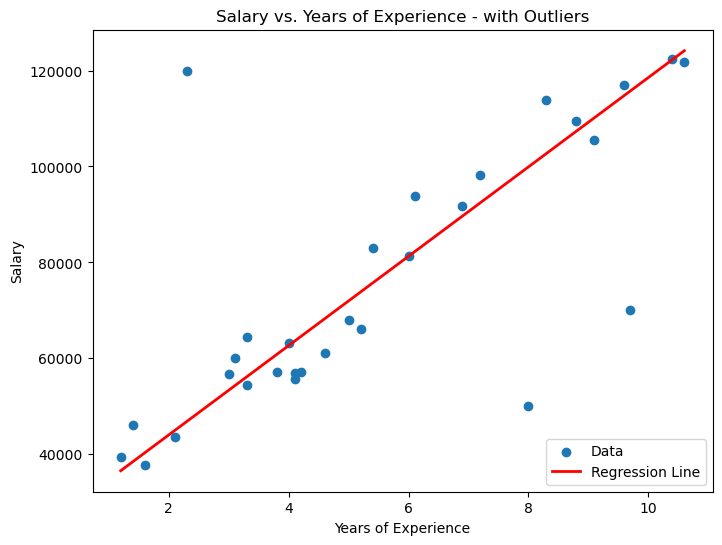

In [21]:
beta0 = 25400.91899  # copied from summary
beta1 = 9314.60608   # copied from summary

x_line = np.linspace(salary_data_outliers["YearsExperience"].min(), salary_data_outliers["YearsExperience"].max(), 100)
y_line = beta0 + beta1 * x_line

plt.figure(figsize=(8, 6))
plt.scatter(salary_data_outliers["YearsExperience"], salary_data_outliers["Salary"], label="Data")
plt.plot(x_line, y_line, color='red', linewidth=2, label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs. Years of Experience - with Outliers")
plt.legend()
plt.show()

#### Inference with Bayesian posterior analysis and MCMC diagnostics

* The r_hat statistic for all parameters are all less than 1.01 and are very close to 1, indicating the chains are mixing well and converging on the same results.
* From the scatterplot above, it seems that even with the three outliers introduced, our algorithm still did a good job estimating beta0 and beta1, as the resulting regression line fits the data well. The mean estimate of sigma is still relatively low (4269.18785), as the regression line fits the data well and explains most of the variation between data points.
* The 94% HDIs for beta0, beta1, alpha, and beta parameters are relatively narrow given the large scale of the data, indicating the model is confident about these estimates. Notice, however, that the 94% HDI for sigma is approximately double the width of the HDI for sigma in Question 2. This is because the outliers deviate from the regression line by a significant amount, meaning the model now has to account for more uncertainty in the error terms.
* From the trace plots in this example, we see that the chains for beta0, beta1, alpha, and beta are in agreement and have converged closely for each parameter. The trace plots of sigma, however, show a little more disagreement between the chains, even though they still converge around the same area.
* In this example, we took a total of 12,000 draws. ess_bulk is approximately 4398 for beta0, 4520 for beta1, 531 for sigma, 2259 for alpha, and 637 for beta. This means we took the rough equivalent of this many independent samples for each respective parameter. This amount of independent samples seem sufficient for beta0, beta1, alpha, and beta, as the chains have converged on the same results and have mixed well, as seen from the summary table statistics and trace plots. On the other hand, ess_bulk for sigma has dropped to 531, when in Question 2 it was 6185. This is because the outliers introduce more uncertainty to the model, making the algorithm consider a wider range of residuals, leading to higher autocorrelation in the samples of sigma.

Overall, our analysis shows that this algorithm still provided a reliable estimate of the relationship between Years of Experience and Salary using Bayesian linear regression, as our model identified the three outliers introduced and gave them a lower amount of influence over the regression line. Our results for beta0 and beta1 are similar to our results in Question 2, but our results for sigma are more uncertain, due to the significant deviations introduced by the outliers.